In [39]:
import sys
import pandas as pd
from PIL import Image
import seaborn as sns
import os

sys.path.append(os.path.abspath(os.path.join('..')))

In [5]:
from config.config import RAW_DATA_DIR
data_directory = RAW_DATA_DIR / "raw"

Mapping image file paths to labels

In [30]:
data = []
accepted_extensions = ('png', 'jpg', 'jpeg', 'webp')

for folder in ["AiArtData", "RealArt"]:
    path_to_folder = data_directory / folder
    
    label = 1 if folder == 'AiArtData' else 0

    for file in os.listdir(path=path_to_folder):
        if file.lower().endswith(accepted_extensions):
            data.append({
                'filepath': path_to_folder / file,
                'label': label
            })

In [25]:
df = pd.DataFrame(data=data)

Checking the number of AI and Human Images

In [26]:
ai_image, human_image = [], []
ai_count, human_count = 0, 0
for folder in ["AiArtData", "RealArt"]:
    path_to_folder = data_directory / folder

    for file in os.listdir(path=path_to_folder):
        if folder == "AiArtData":
            ai_count+=1
        elif folder == "RealArt":
            human_count+=1

ai_count, human_count


(539, 436)

In [27]:
df['label'].value_counts()

label
1    539
0    434
Name: count, dtype: int64

To see which files aren't being added to the DataFrame

In [37]:
ghosts = []
for folder in ['AiArtData', 'RealArt']:
    path_to_folder = data_directory / folder
    for image_file in os.listdir(path_to_folder):
        if not image_file.lower().endswith(accepted_extensions):
            ghosts.append(image_file)

print(f"Length of ghosts: {len(ghosts)}.\nGhosts: {ghosts}")

Length of ghosts: 2.
Ghosts: ['1707541234037', 'black-american-portraits-130.gif']


Exploring the Images themselves

Checking Aspect Ratio of Images

<Axes: xlabel='aspect_ratio', ylabel='Count'>

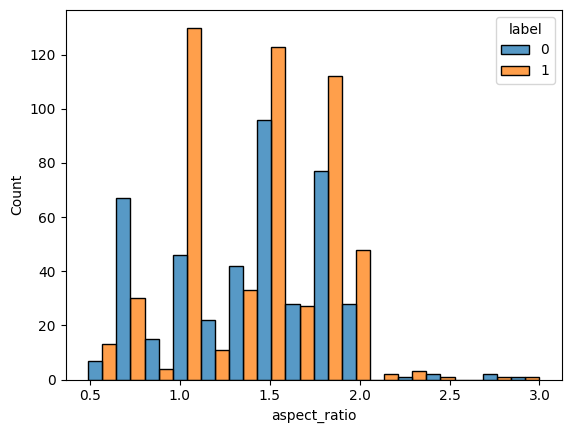

In [ ]:
def get_image_info(path):
    try:
        with Image.open(path) as img:
            return img.size
    except:
        return (None, None)

df[['width', 'height']] = df['filepath'].apply(lambda x: pd.Series(get_image_info(x)))
df['aspect_ratio'] = df['width'] / df['height']

sns.histplot(data=df, x='aspect_ratio', hue='label', multiple='dodge')

Checking AI and Human Generated Images for Manual Inspection

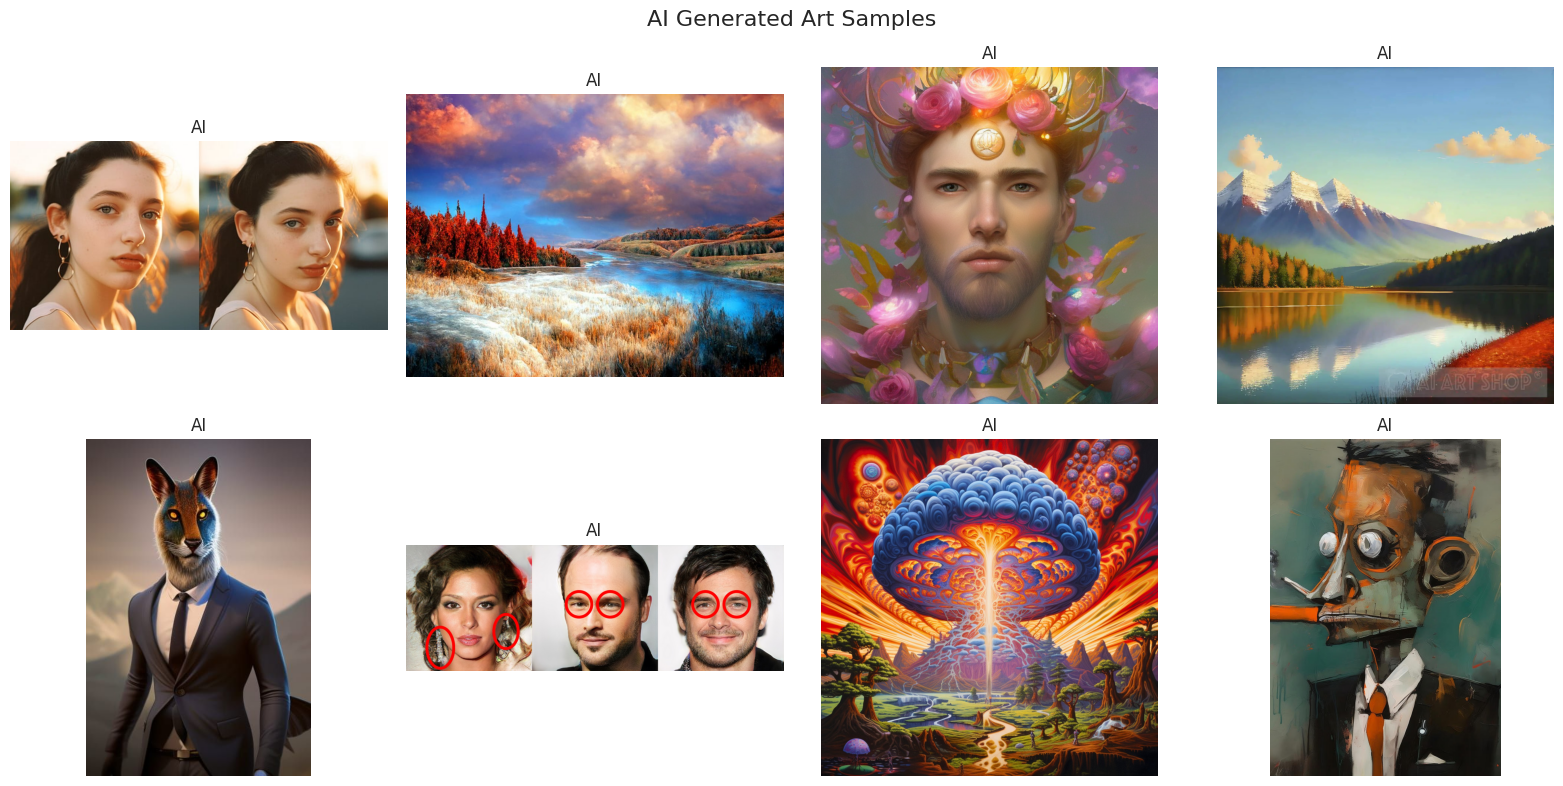

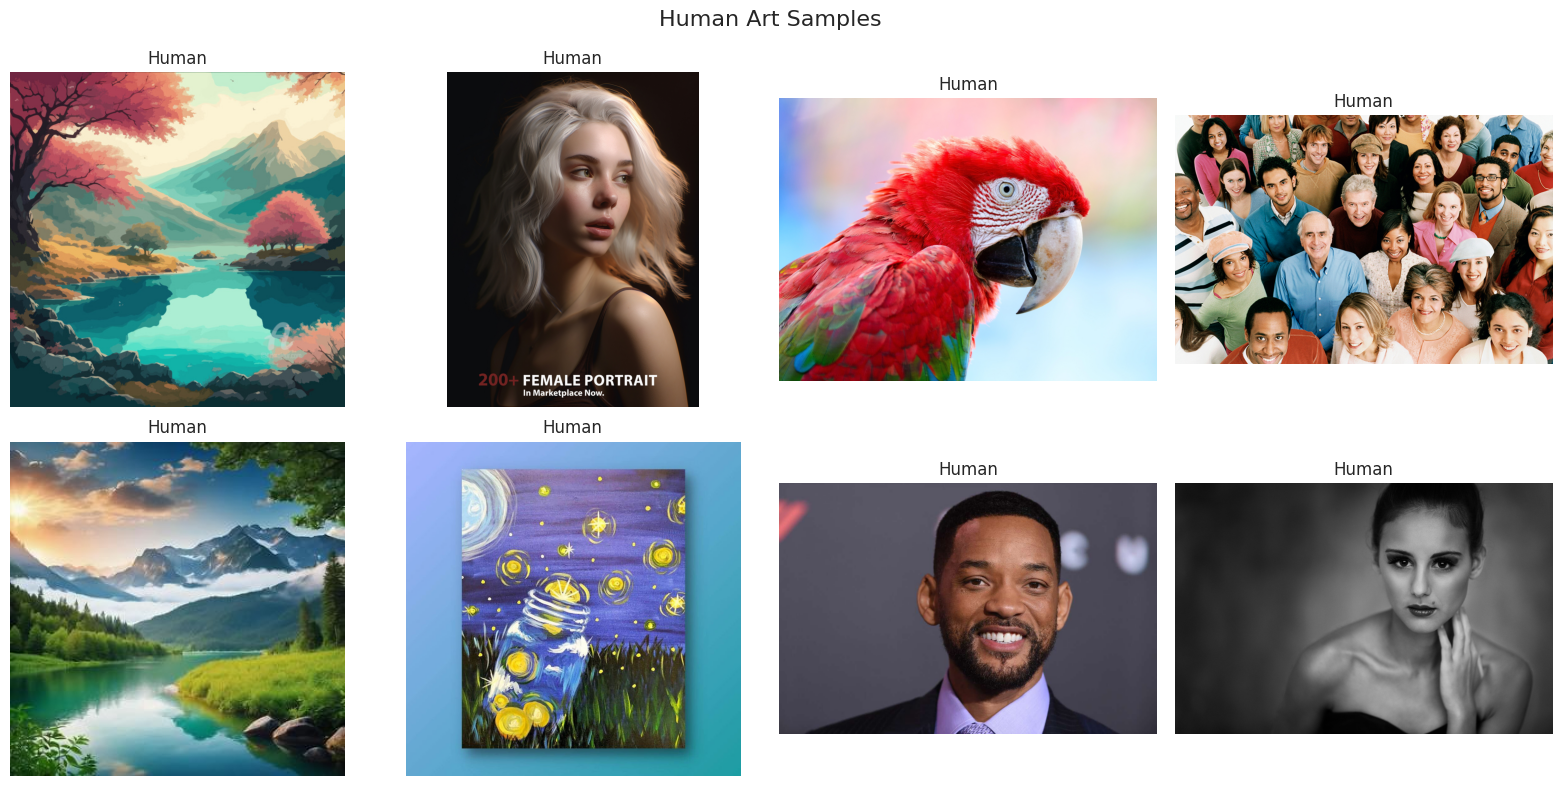

In [50]:
import matplotlib.pyplot as plt

def plot_grid(df, label_value, title):
    samples = df[df['label'] == label_value].sample(8)['filepath'].values
    
    plt.figure(figsize=(16, 8))
    
    for i, img_path in enumerate(samples):
        plt.subplot(2, 4, i + 1)
        img = Image.open(img_path).convert("RGB")
        plt.imshow(img)
        plt.title(f"{'AI' if label_value == 1 else 'Human'}")
        plt.axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

plot_grid(df, 1, "AI Generated Art Samples")
plot_grid(df, 0, "Human Art Samples")